In [2]:
%load_ext autoreload
%autoreload 2

# SPHERE

In [1]:
from pytorch_lightning.loggers import WandbLogger

wandb_logger = WandbLogger(log_model="all")
checkpoint_reference = "jkociniak/normal-vectors/model-y7jtebw7:v0"
wandb_logger.download_artifact(checkpoint_reference, artifact_type="model")

wandb:   1 of 1 files downloaded.  


'/Users/janko/Code/Normal-vectors/notebooks/after_thesis/artifacts/model-y7jtebw7:v0'

In [2]:
# load checkpoint
from train_correction import LitManifoldMetricCorrector
path = '/Users/janko/Code/Normal-vectors/notebooks/after_thesis/artifacts/model-y7jtebw7:v0/model.ckpt'
model = LitManifoldMetricCorrector.load_from_checkpoint(path)

/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.10/Python
  Referenced from: <D39B31F4-BCFB-3005-A82F-3F010BF36435> /Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing

In [3]:
from src.datasets.euclidean import Sphere3DDataset
import torch

ds_params = dict(n_points=100, polar_angle_range=(0, torch.pi/2), azimuth_range=(0, torch.pi/2))
dataset = Sphere3DDataset(**ds_params)
points = dataset.data_list[0].pos

Seed set to 42


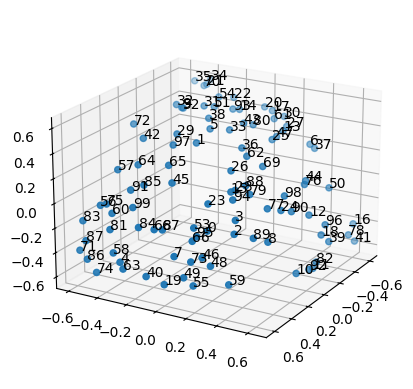

In [4]:
import matplotlib.pyplot as plt
# plot the points with text labels (id of point)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2])
for i, txt in enumerate(range(len(points))):
    ax.text(points[i, 0], points[i, 1], points[i, 2], str(i))
ax.view_init(elev=20, azim=30)

In [5]:
from src.utils.callbacks import SineExperimentsLogger

interp_params = {
    'starting_idx': 58,
    'ending_idx': 25,
    'n_interps': 20,
    'rgd_params': dict(print_iterations=False, max_iter=1000, step_size=0.1, tol=1e-4)
}

preds = SineExperimentsLogger.compute_interps(model.manifold, points, **interp_params).detach()

Calculating interpolations: 100%|██████████| 20/20 [00:13<00:00,  1.48it/s]


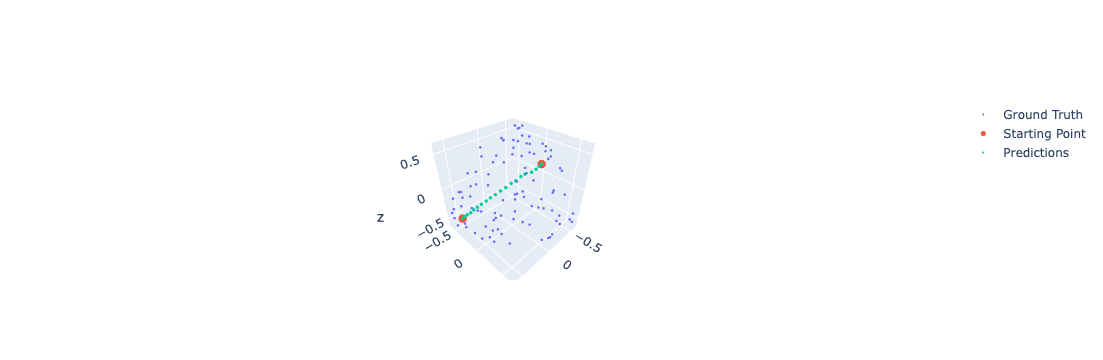

In [6]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode='markers', name='Ground Truth',
                        marker = dict(size=1.5)))

ids = [interp_params['starting_idx'], interp_params['ending_idx']]
fig.add_trace(go.Scatter3d(x=points[ids, 0], y=points[ids, 1], z=points[ids, 2], mode='markers', name='Starting Point', marker=dict(size=5)))
        
fig.add_trace(go.Scatter3d(x=preds[:, 0], y=preds[:, 1], z=preds[:, 2], mode='markers', name='Predictions',
                        marker=dict(size=2)))

# TORUS

In [7]:
from pytorch_lightning.loggers import WandbLogger

wandb_logger = WandbLogger(log_model="all")
checkpoint_reference = "jkociniak/normal-vectors/model-x4bi81lx:v0"
path = wandb_logger.download_artifact(checkpoint_reference, artifact_type="model")
path

wandb:   1 of 1 files downloaded.  


'/Users/janko/Code/Normal-vectors/notebooks/after_thesis/artifacts/model-x4bi81lx:v0'

In [8]:
# load checkpoint
from train_correction import LitManifoldMetricCorrector
ckpt_path = path + "/model.ckpt"
model = LitManifoldMetricCorrector.load_from_checkpoint(ckpt_path)

In [9]:
from src.datasets.euclidean import Torus3DDataset

ds_params = dict(n_points=100)
dataset = Torus3DDataset(**ds_params)
points = dataset.data_list[0].pos

Seed set to 42


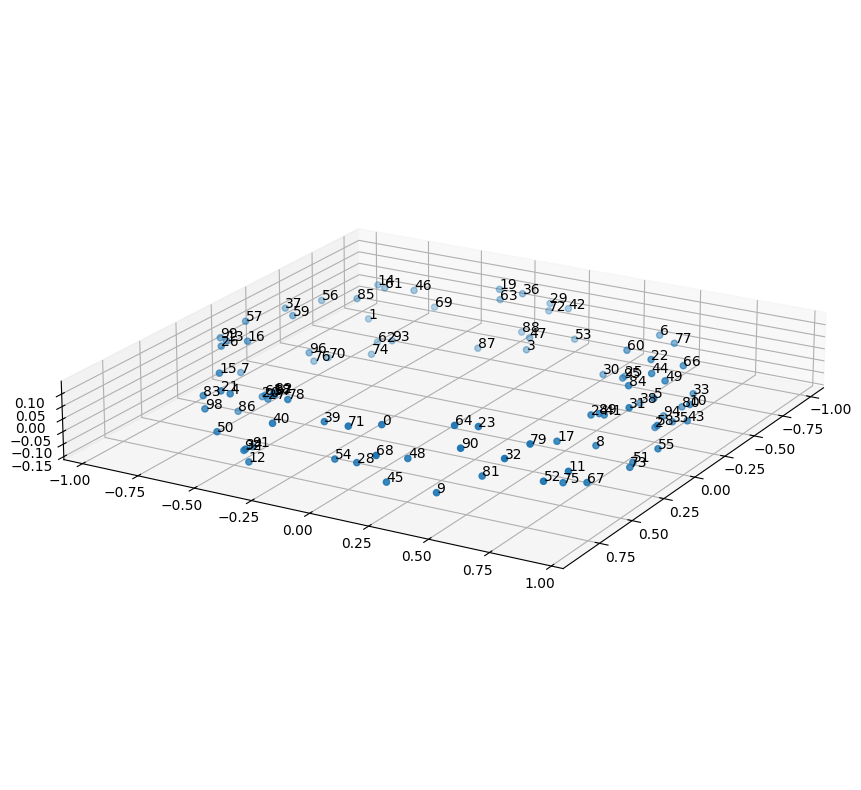

In [10]:
import matplotlib.pyplot as plt
# plot the points with text labels (id of point)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2])
for i, txt in enumerate(range(len(points))):
    ax.text(points[i, 0], points[i, 1], points[i, 2], str(i))
ax.set_aspect('equal')
ax.view_init(elev=20, azim=30)

Calculating interpolations: 100%|██████████| 50/50 [02:17<00:00,  2.74s/it]


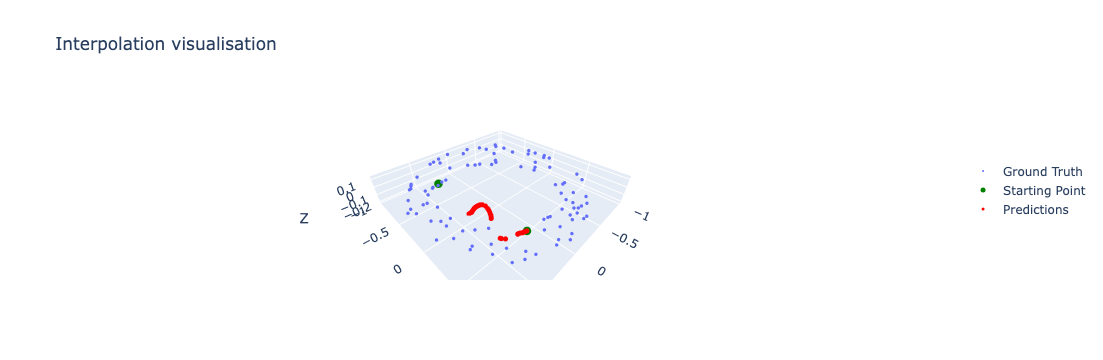

In [11]:
from src.utils.callbacks import SineExperimentsLogger

interp_params = {
    'starting_idx': 86,
    'ending_idx': 17,
    'n_interps': 50,
    'rgd_params': dict(print_iterations=False, max_iter=1000, step_size=0.1, tol=1e-4)
}

preds = SineExperimentsLogger.compute_interps(model.manifold, points, **interp_params).detach()

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode='markers', name='Ground Truth',
                        marker = dict(size=2)))
ids = [interp_params['starting_idx'], interp_params['ending_idx']]
fig.add_trace(go.Scatter3d(x=points[ids, 0], y=points[ids, 1], z=points[ids, 2], mode='markers', name='Starting Point', marker=dict(size=5, color='green')))
        
fig.add_trace(go.Scatter3d(x=preds[:, 0], y=preds[:, 1], z=preds[:, 2], mode='markers', name='Predictions',
                        marker=dict(size=3, color='red')))

fig.update_layout(
    title='Interpolation visualisation',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    legend=dict(x=1.05, y=0.5)
)

# Normal space estimation

In [1]:
from pytorch_lightning.loggers import WandbLogger

wandb_logger = WandbLogger(log_model="all")
checkpoint_reference = "jkociniak/normal-vectors/model-mj4xa59d:v0"
path = wandb_logger.download_artifact(checkpoint_reference, artifact_type="model")
path

wandb:   1 of 1 files downloaded.  


'/Users/janko/Code/Normal-vectors/notebooks/after_thesis/artifacts/model-mj4xa59d:v0'

In [2]:
# load checkpoint
from train_correction import LitManifoldMetricCorrector
ckpt_path = path + "/model.ckpt"
model = LitManifoldMetricCorrector.load_from_checkpoint(ckpt_path)

/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.10/Python
  Referenced from: <D39B31F4-BCFB-3005-A82F-3F010BF36435> /Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing

In [3]:
from src.datasets.euclidean import Custom3DDataset

dataset = Custom3DDataset()
points = dataset.data_list[0].pos

Seed set to 42


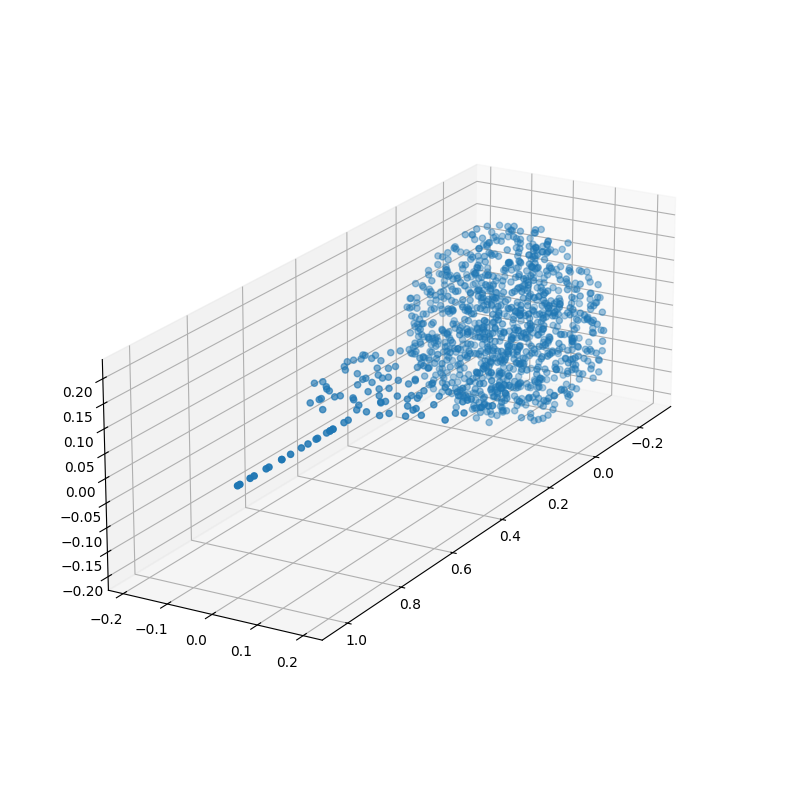

In [5]:
import matplotlib.pyplot as plt
# plot the points with text labels (id of point)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2])
# for i, txt in enumerate(range(len(points))):
#     ax.text(points[i, 0], points[i, 1], points[i, 2], str(i))
ax.set_aspect('equal')
ax.view_init(elev=20, azim=30)

In [10]:
from src.utils.callbacks import SineExperimentsLogger

interp_params = {
    'starting_idx': 678,
    'ending_idx': 81,
    'n_interps': 20,
    'rgd_params': dict(print_iterations=False, max_iter=1000, step_size=0.1, tol=1e-4)
}

preds = SineExperimentsLogger.compute_interps(model.manifold, points, **interp_params).detach()

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode='markers', name='Ground Truth',
                        marker = dict(size=2)))
ids = [interp_params['starting_idx'], interp_params['ending_idx']]
fig.add_trace(go.Scatter3d(x=points[ids, 0], y=points[ids, 1], z=points[ids, 2], mode='markers', name='Starting Point', marker=dict(size=5, color='green')))
        
fig.add_trace(go.Scatter3d(x=preds[:, 0], y=preds[:, 1], z=preds[:, 2], mode='markers', name='Predictions',
                        marker=dict(size=3, color='red')))

fig.update_layout(
    title='Interpolation visualisation',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    legend=dict(x=1.05, y=0.5)
)

Calculating interpolations: 100%|██████████| 20/20 [00:34<00:00,  1.75s/it]


## Very noisy sine

In [11]:
from pytorch_lightning.loggers import WandbLogger

wandb_logger = WandbLogger(log_model="all")
checkpoint_reference = "jkociniak/normal-vectors/model-n9znbd64:v0"
path = wandb_logger.download_artifact(checkpoint_reference, artifact_type="model")
path

wandb:   1 of 1 files downloaded.  


'/Users/janko/Code/Normal-vectors/notebooks/after_thesis/artifacts/model-n9znbd64:v0'

In [12]:
# load checkpoint
from train_correction import LitManifoldMetricCorrector
ckpt_path = path + "/model.ckpt"
model = LitManifoldMetricCorrector.load_from_checkpoint(ckpt_path)

In [13]:
from src.datasets.euclidean import NoisySineDataset

dataset = NoisySineDataset(n_points=200, noise_scale=0.3)
points = dataset.data_list[0].pos

Seed set to 42


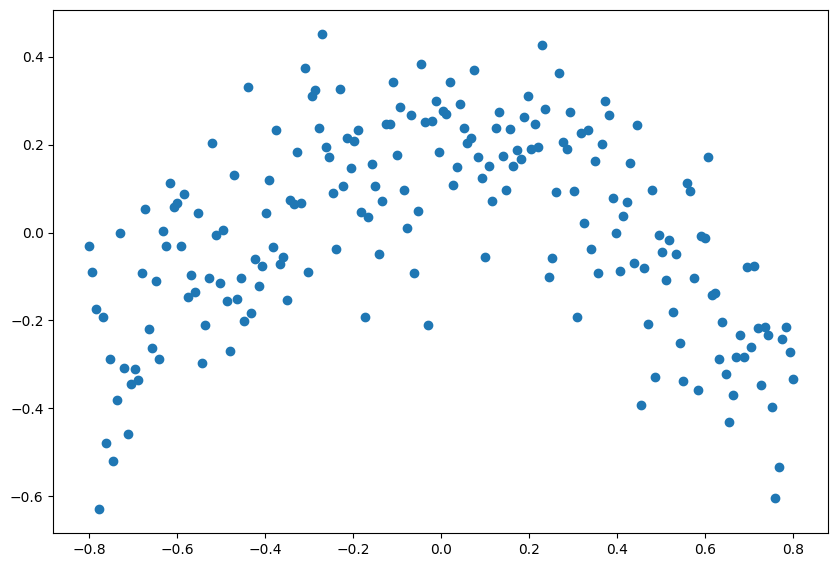

In [14]:
import matplotlib.pyplot as plt
# plot the points with text labels (id of point)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.scatter(points[:, 0], points[:, 1])
# for i, txt in enumerate(range(len(points))):
#     ax.text(points[i, 0], points[i, 1], points[i, 2], str(i))
ax.set_aspect('equal')

In [15]:
from src.utils.callbacks import SineExperimentsLogger

interp_params = {
    'starting_idx': 10,
    'ending_idx': 190,
    'n_interps': 20,
    'rgd_params': dict(print_iterations=False, max_iter=1000, step_size=0.1, tol=1e-4)
}

preds = SineExperimentsLogger.compute_interps(model.manifold, points, **interp_params).detach()

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=points[:, 0], y=points[:, 1], mode='markers', name='Ground Truth',
                        marker = dict(size=2)))
ids = [interp_params['starting_idx'], interp_params['ending_idx']]
fig.add_trace(go.Scatter(x=points[ids, 0], y=points[ids, 1], mode='markers', name='Starting Point', marker=dict(size=5, color='green')))
        
fig.add_trace(go.Scatter(x=preds[:, 0], y=preds[:, 1], mode='markers', name='Predictions',
                        marker=dict(size=3, color='red')))

fig.update_layout(
    title='Interpolation visualisation',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        aspectmode='data'
    ),
    legend=dict(x=1.05, y=0.5)
)

Calculating interpolations: 100%|██████████| 20/20 [00:14<00:00,  1.35it/s]


# 2D MNIST PCA (classes 3, 9, 0)

In [63]:
from pytorch_lightning.loggers import WandbLogger

wandb_logger = WandbLogger(log_model="all")
checkpoint_reference = "jkociniak/normal-vectors/model-eyl4365y:v0"
#checkpoint_reference = "jkociniak/normal-vectors/model-go4ldgra:v0"
path = wandb_logger.download_artifact(checkpoint_reference, artifact_type="model")
path

wandb:   1 of 1 files downloaded.  


'/Users/janko/Code/Normal-vectors/notebooks/after_thesis/artifacts/model-eyl4365y:v0'

In [64]:
from train_correction import LitManifoldMetricCorrector
ckpt_path = path + "/model.ckpt"
model = LitManifoldMetricCorrector.load_from_checkpoint(ckpt_path)

In [1]:
from src.datasets.euclidean.mnist import MNISTPCADataset
params = MNISTPCADataset.param_sets['MNIST PCA 2D, CLASSES [3, 9, 0]']
dataset = MNISTPCADataset(**params)
points = dataset.data_list[0].pos
print(points.shape)

/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.10/Python
  Referenced from: <D39B31F4-BCFB-3005-A82F-3F010BF36435> /Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/janko/PycharmProjects/ponita/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing

torch.Size([999, 2])


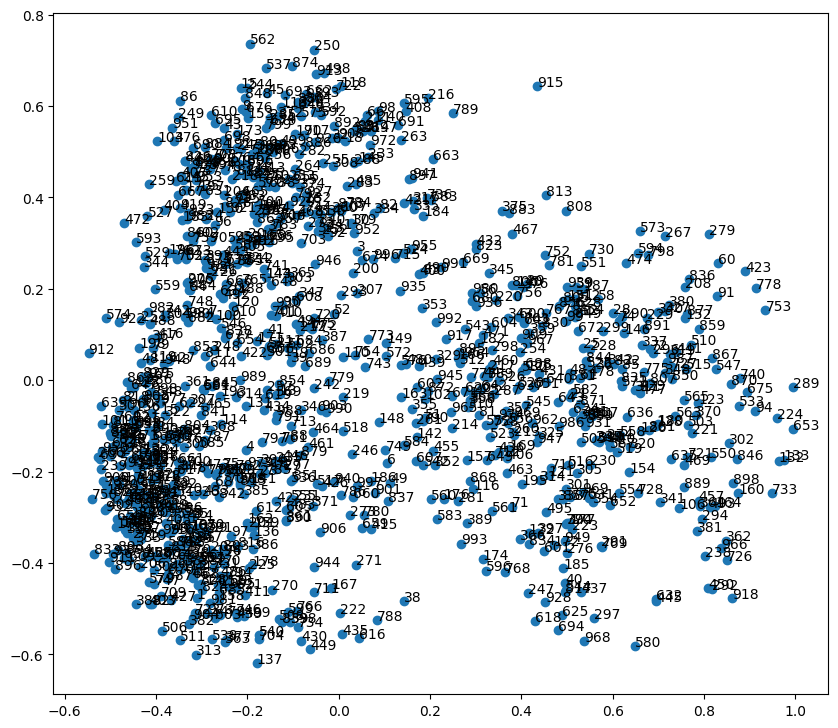

In [66]:
import matplotlib.pyplot as plt
# plot the points with text labels (id of point)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.scatter(points[:, 0], points[:, 1])
for i, txt in enumerate(range(len(points))):
    ax.text(points[i, 0], points[i, 1], str(i))
ax.set_aspect('equal')

In [73]:
from src.utils.callbacks import SineExperimentsLogger

interp_params = {
    'starting_idx': 234,
    'ending_idx': 506,
    'n_interps': 20,
    'rgd_params': dict(print_iterations=False, max_iter=1000, step_size=1e-3, tol=1e-5)
}

preds = SineExperimentsLogger.compute_interps(model.manifold, points, **interp_params).detach()

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=points[:, 0], y=points[:, 1], mode='markers', name='Ground Truth',
                        marker = dict(size=2)))
ids = [interp_params['starting_idx'], interp_params['ending_idx']]
fig.add_trace(go.Scatter(x=points[ids, 0], y=points[ids, 1], mode='markers', name='Starting Point', marker=dict(size=5, color='green')))
        
fig.add_trace(go.Scatter(x=preds[:, 0], y=preds[:, 1], mode='markers', name='Predictions',
                        marker=dict(size=3, color='red')))

fig.update_layout(
    title='Interpolation visualisation',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        aspectmode='data'
    ),
    legend=dict(x=1.05, y=0.5)
)

Calculating interpolations: 100%|██████████| 20/20 [00:29<00:00,  1.46s/it]


[]

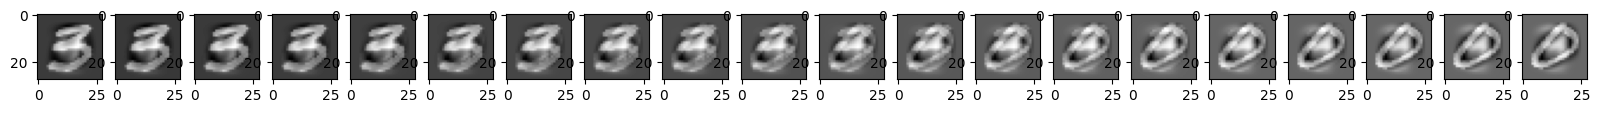

In [52]:
import numpy as np
sid = interp_params['starting_idx']
eid = interp_params['ending_idx']
n_interps = interp_params['n_interps']
ts = np.linspace(0, 1, n_interps, endpoint=True)

results = []
for t, pred in zip(ts, preds):
    res = dataset.reconstruct_from_pca_interpolant(start=dataset.og_data[sid], end=dataset.og_data[eid], 
                                                   t=t, pred=pred)
    results.append(res.reshape(28, 28))

n_matrices = 20
# Create default titles if none provided
titles = [f"Interp {i+1}" for i in range(n_matrices)]

# Validate input
if len(titles) != n_matrices:
    raise ValueError("Number of titles must match number of matrices")

# Create figure and axes
fig, axes = plt.subplots(1, n_matrices, figsize=(20, 4))
for ax, matrix, title in zip(axes, results[:n_matrices], titles):
    # Display the matrix
    ax.imshow(np.array(matrix), cmap='gray')
plt.plot()

# 

In [ ]:
jkociniak/normal-vectors/model-go4ldgra:v0